PHOEBE: passband "Bolometric:900-40000" has a newer version available.  Run phoebe.list_passband_online_history("Bolometric:900-40000") to get a list of available changes and phoebe.update_passband("Bolometric:900-40000") or phoebe.update_all_passbands() to update.
PHOEBE: passband "Johnson:V" has a newer version available.  Run phoebe.list_passband_online_history("Johnson:V") to get a list of available changes and phoebe.update_passband("Johnson:V") or phoebe.update_all_passbands() to update.
Parameter: requiv@secondary@component
                       Qualifier: requiv
                     Description: Equivalent radius
                           Value: 3.8465159282644805 solRad
                  Constrained by: requiv_max@secondary@component
                      Constrains: logg@secondary@component, requivratio@binary@component, requivsumfrac@binary@component
                      Related to: mass@secondary@component, logg@secondary@component, requiv@primary@component, requivratio@

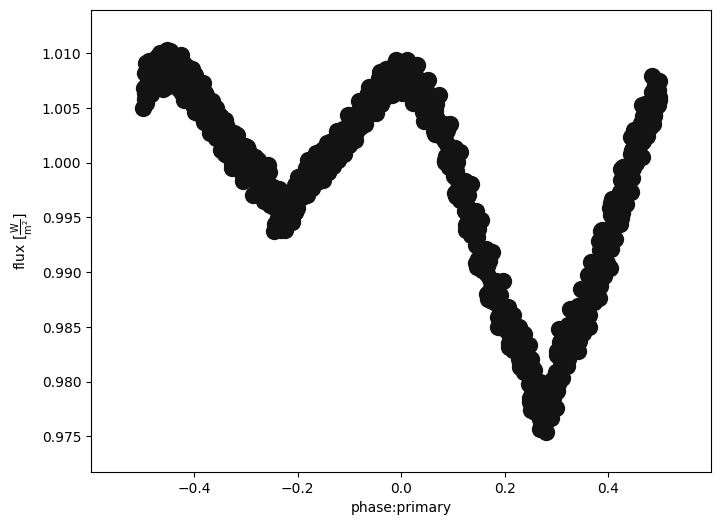

100%|██████████| 1086/1086 [00:14<00:00, 74.21it/s]


<ParameterSet: 4 parameters | qualifiers: flux_scale, times, comments, fluxes>

In [1]:
import phoebe
from phoebe import u #units
import numpy as np

%matplotlib inline

logger = phoebe.logger(clevel='WARNING')

raw_fluxes = np.genfromtxt('J071951.40-240400.6_LightCurve.txt').T[1]
times = np.genfromtxt('J071951.40-240400.6_LightCurve.txt').T[0]
raw_sigmas = np.genfromtxt('J071951.40-240400.6_LightCurve.txt').T[2]

# Calculate relative flux and sigma to pass to dataset
median_flux = np.median(raw_fluxes)
fluxes = raw_fluxes / median_flux
sigmas = raw_sigmas / median_flux

b = phoebe.default_binary(semidetached='secondary')
b.add_dataset('lc',
              times=times,
              fluxes=fluxes,
              sigmas=sigmas,
              dataset='lc01',
              passband='TESS:T'
              )

# Approximations & guesses
b.set_value_all('atm', 'blackbody')
b.set_value_all('ld_mode_bol', 'manual')
b.set_value_all('ld_func_bol', 'linear')
b.set_value_all('ld_coeffs_bol', [0.5])
b.set_value_all('ld_mode', 'manual')
b.set_value_all('ld_func', 'linear')
b.set_value_all('ld_coeffs', [0.5])
b.set_value(qualifier='teff', component='primary', value=17000)
b.set_value('gravb_bol@primary', 0.9)
b.set_value('gravb_bol@secondary', 0.9)
b.set_value('irrad_frac_refl_bol@primary', 1.0)
b.set_value('irrad_frac_refl_bol@secondary', 1.0)

b.set_value('pblum_mode', 'dataset-scaled')

# Known information
b['period@binary'] = 0.5055155277660734 * 2
b['teff@primary'] = 21000
b['teff@secondary'] = 15138
b['requiv@primary'] = 2

# Calculating semi major axis
sol = 1.98*10**30
sma = (((6.67*10**-11)*((8+6)*sol)/(4*(np.pi**2)))*(86400**2))**(1/3)
b['sma@binary'] = sma/(6.957*10**8)
print(b['requiv@secondary@component'])
print(b['requiv_max@secondary@component'])
# b['requiv@secondary@component'] = 3

b.plot(dataset='lc01', x='phases:primary', show=True)

b.run_compute()

Mon, 22 Jun 2026 16:23 SOLVER       WARNING binning input observations (len: 1086) with 500 bins (ignores sigmas)
Mon, 22 Jun 2026 16:23 SOLVER       WARNING phase-binning resulted in bin(s) with <=1 entries, ignoring sigmas as cannot determine per-bin sigmas.
/Users/kylechen/phoebe-env/lib/python3.11/site-packages/phoebe/dependencies/ligeor/eclipse/eb_params.py:76: UserWarning: Cannot esimate eccentricty and argument of periastron: incomplete geometry information
  warnings.warn('Cannot esimate eccentricty and argument of periastron: incomplete geometry information')


Flipped requivsumfrac to solve for requiv@primary
Flipped teffratio to solve for teff@secondary
ParameterSet: 21 parameters
R   orbit@lcgeo_solution@solution: binary
R  input_phases@lcgeo_solution...: [0.50123909 0.50323698 0.50523488
 ... 0.49419487 0.49619276
 0.49819066]
R  input_fluxes@lcgeo_solution...: [1.00498508 1.00682994 1.00633029
 ... 1.00631504 1.00582097
 1.0059621 ]
R  input_sigmas@lcgeo_solution...: []
R  analytic_phases@lcgeo_solut...: [0.50123909 0.50323698 0.50523488
 ... 0.49419487 0.49619276
 0.49819066]
R  analytic_fluxes@lcgeo_solut...: {'polyfit': array([1.0060991 , 1.00622755, 1.00635137, 1.00647055, 1.0065851 ,
       1.006695  , 1.00680026, 1.00690089, 1.00699688, 1.00708822,
       1.00717493, 1.00725701, 1.00733444, 1.00740723, 1.00747539,
       1.0075389 , 1.00759778, 1.00765202, 1.00770162, 1.00774658,
       1.00778691, 1.00782259, 1.00785364, 1.00788005, 1.00790181,
       1.00791895, 1.00793144, 1.00793929, 1.0079425 , 1.00794108,
       1.00793502, 1

100%|██████████| 1086/1086 [00:18<00:00, 58.20it/s]


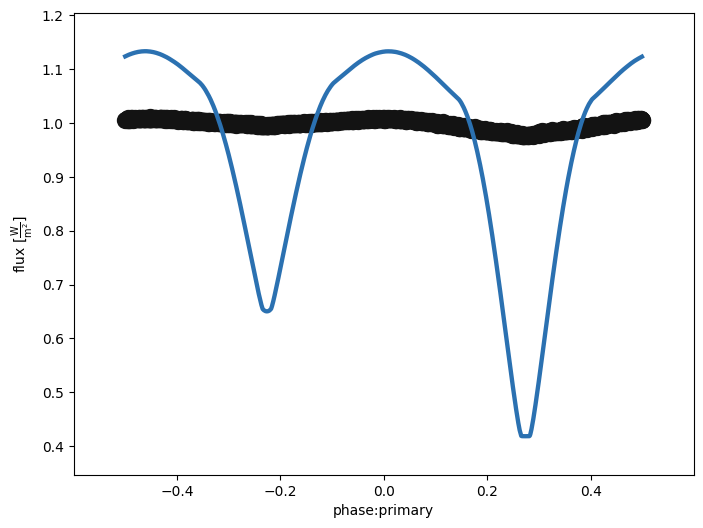

In [2]:
# Lightcurve Geometry Estimater

b.add_solver('estimator.lc_geometry', solver='lcgeo_solver', analytical_model='polyfit', overwrite=True)
b.run_solver(solver='lcgeo_solver', solution='lcgeo_solution', overwrite=True)

# Creating a function to flip constraints if needed
def safe_flip_constraint(b, constraint, solve_for):
    """
    Flip a PHOEBE constraint only if possible.
    If it was already flipped in a previous cell run, skip cleanly.
    """
    try:
        b.flip_constraint(constraint, solve_for=solve_for)
        print(f"Flipped {constraint} to solve for {solve_for}")
    except Exception as e:
        print(f"Skipped flipping {constraint}: {e}")

safe_flip_constraint(b=b, constraint='requivsumfrac', solve_for='requiv@primary')
safe_flip_constraint(b=b, constraint='teffratio', solve_for='teff@secondary')

print(b.filter(context='solution', solution='lcgeo_solution'))

adopt_list = [
    't0_supconj@binary@orbit@component',
    'ecc@binary@orbit@component',
    'per0@binary@orbit@component',
    'requivsumfrac@binary@orbit@component',
]

b.adopt_solution(
    solution='lcgeo_solution'
    , adopt_parameters=
        adopt_list
    )
b.run_compute(model='lcgeo_model', overwrite=True)

_ = b.plot(
    dataset='lc01',
    model='lcgeo_model',
    x='phases:primary',
    show=True
)


In [3]:
print("t0_supconj:", b.get_value('t0_supconj@binary@orbit'))
print("ecc:", b.get_value('ecc@binary'))
print("per0:", b.get_value('per0@binary'))
print("requivsumfrac:", b.get_value('requivsumfrac@binary'))

t0_supconj: 1492.5589548375835
ecc: 0.0
per0: 90.0
requivsumfrac: 0.7063634661999338


In [4]:
# Powell Optimizer

safe_flip_constraint(b=b, constraint='requiv@primary', solve_for='requivsumfrac@binary')
safe_flip_constraint(b=b, constraint='teff@secondary', solve_for='teffratio@binary')

b.set_value('pblum_mode@lc01', 'dataset-scaled')

b.add_solver('optimizer.powell', solver='powell_solver', overwrite=True)

b.set_value('fit_parameters@powell_solver', [
    'incl@binary',
    'requiv@primary',
    't0_supconj@binary',
])

b.set_value('maxiter@powell_solver', 200)
b.set_value('xtol@powell_solver', 1e-3)
b.set_value('ftol@powell_solver', 1e-3)

b.run_solver('powell_solver', solution='powell_solution', overwrite=True)

Flipped requiv@primary to solve for requivsumfrac@binary
Flipped teff@secondary to solve for teffratio@binary


  0%|          | 0/200 [00:00<?, ?it/s]Mon, 22 Jun 2026 16:26 SOLVER       WARNING received error while setting values: value of incl=267.9044451174909 deg not within limits of [<Quantity 0. deg>, <Quantity 180. deg>]. lnprobability=-inf
Mon, 22 Jun 2026 16:26 SOLVER       WARNING received error while setting values: value of incl=206.18705968767551 deg not within limits of [<Quantity 0. deg>, <Quantity 180. deg>]. lnprobability=-inf
Mon, 22 Jun 2026 16:26 UNIVERSE     WARNING target_volume of 0.22959922447470388 slightly over critical value, likely due to numerics: setting to critical value of 0.2295992244747038
Mon, 22 Jun 2026 16:26 UNIVERSE     WARNING target_volume of 0.22959922447470388 slightly over critical value, likely due to numerics: setting to critical value of 0.2295992244747038
Mon, 22 Jun 2026 16:26 UNIVERSE     WARNING target_volume of 0.22959922447470388 slightly over critical value, likely due to numerics: setting to critical value of 0.2295992244747038
Mon, 22 Jun 2

<ParameterSet: 11 parameters | qualifiers: message, success, fitted_values, comments, initial_values, adopt_parameters, niter, fitted_units, adopt_distributions, adopt_values, fitted_twigs>

100%|██████████| 1086/1086 [00:03<00:00, 348.22it/s]


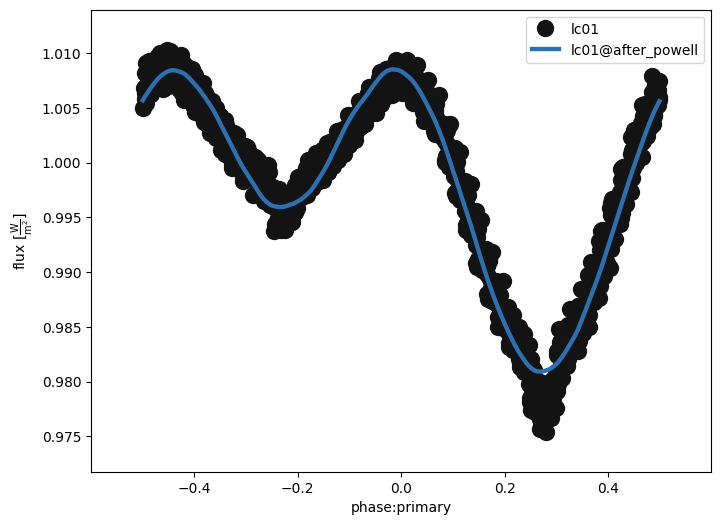

Inclination: 159.59668610123063
Temperature of Primary Star (in K): 21000.0
Temperature of Secondary Star (in K): 15137.999999999998
Equivalent Radius of Secondary (Sol): 3.8465159282644805
Equivalent Radius of Primary (Sol): 1.5360075942651437
Semi Major Axis (Sol): 10.12605462848939


/Users/kylechen/phoebe-env/lib/python3.11/site-packages/phoebe/dependencies/autofig/call.py:1305: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  artist = ax.scatter(*datapoint,


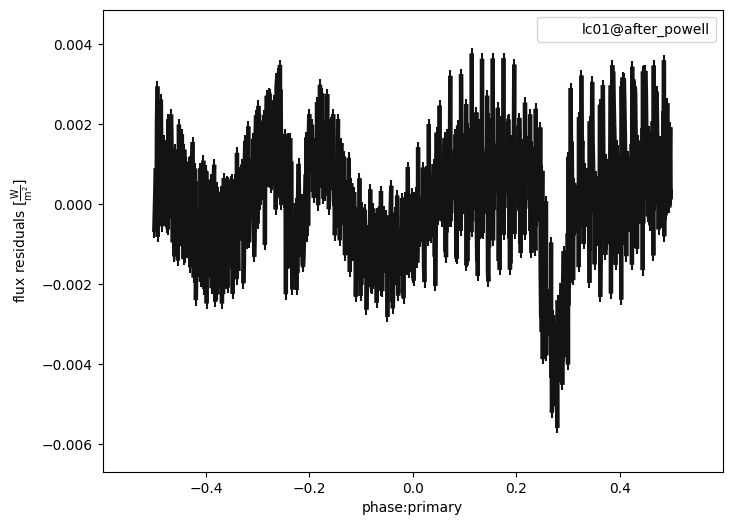

In [5]:
b.adopt_solution(solution='powell_solution')
b.run_compute(model='after_powell', compute='phoebe01', overwrite=True)
_ = b.plot(model='after_powell', x='phases:primary', 
           linestyle={'model': 'solid'},
           legend=True,
           show=True)

print("Inclination:", b.get_value('incl@binary@orbit@component'))
print("Temperature of Primary Star (in K):", b.get_value('teff@primary'))
print("Temperature of Secondary Star (in K):", b.get_value('teff@secondary@star'))
print("Equivalent Radius of Secondary (Sol):", b.get_value('requiv@secondary@star@component'))
print("Equivalent Radius of Primary (Sol):", b.get_value('requiv@primary@star@component'))
print("Semi Major Axis (Sol):", b.get_value('sma@binary'))

#b.save("phoebe-cloud-job/tic_106588577_powell_ready.phoebe")

_ = b.plot(model='after_powell',
            x='phases:primary', 
           linestyle={'model': 'solid'},
           y='residuals',
           legend=True,
           show=True)

In [6]:
# Second Powell Optimizer to solve for teffratio and requivsumfrac

# safe_flip_constraint(b=b, constraint='requivsumfrac@binary', solve_for='requiv@primary')
# safe_flip_constraint(b=b, constraint='teffratio@binary', solve_for='teff@secondary')

# b.set_value('fit_parameters@powell_solver', [
#     'requivsumfrac@binary',
#     'incl@binary',
#     'teffratio@binary',
#     't0_supconj@binary',
# ])

# b.run_solver('powell_solver', solution='powell_solution_2', overwrite=True)

In [7]:
# Plotting Chi-Squared and Residuals

# b.adopt_solution(solution='powell_solution_2')
# b.run_compute(model='after_powell_2', overwrite=True)

# _ = b.plot(model=['after_powell_2', 'after_powell'],
#            x='phases:primary', 
#            linestyle={'model': 'solid'},
#            legend=True,
#            show=True)

# _ = b.plot(model=['after_powell_2', 'after_powell'],
#             x='phases:primary', 
#            linestyle={'model': 'solid'},
#            y='residuals',
#            legend=True,
#            show=True)

# print("Powell 1 Chi-Squared:", b.calculate_chi2(model='after_powell', dataset='lc01'))
# print("Powell 2 Chi-Squared:", b.calculate_chi2(model='after_powell_2', dataset='lc01'))

# r1 = b.calculate_residuals(model='after_powell')
# r2 = b.calculate_residuals(model='after_powell_2')

# r1_vals = np.asarray(r1.value if hasattr(r1, 'value') else r1)
# r2_vals = np.asarray(r2.value if hasattr(r2, 'value') else r2)

# print("Powell 1 RMS:", np.sqrt(np.mean(r1_vals**2)))
# print("Powell 2 RMS:", np.sqrt(np.mean(r2_vals**2)))

# print("Powell 1 mean abs:", np.mean(np.abs(r1_vals)))
# print("Powell 2 mean abs:", np.mean(np.abs(r2_vals)))

ParameterSet: 20 parameters
R  wrap_central_values@emcee_s...: {'sMnzQrjGYgNpYkCXQEroumARrgvDPu': 159.59668608752924}
R  fitted_twigs@ellcbackend@em...: ['incl@binary@orbit@component' 't0_supconj@binary@orbit@component']
R  fitted_units@ellcbackend@em...: ['deg' 'd']
   adopt_parameters@ellcbacken...: ['incl@binary@orbit@component', 't0_supconj@binary@orbit@component']
   adopt_distributions@ellcbac...: True
   distributions_convert@emcee...: mvsamples
   adopt_values@ellcbackend@em...: True
R  niters@emcee_solution@solution: 200
R  nwalkers@emcee_solution@sol...: 16
R  samples@emcee_solution@solu...: [[[ 159.5915466  1492.55788591]
  [ 159.61010496 1492.557916  ]
  [ 159.60054673 1492.55789467]
  ...
  [ 159.59190984 1492.55787236]
  [ 159.59329115 1492.55784693]
  [ 159.58717178 1492.55790658]]

 [[ 159.59169273 1492.55788522]
  [ 159.62318647 1492.55792137]
  [ 159.60054673 1492.55789467]
  ...
  [ 159.59190984 1492.55787236]
  [ 159.59329115 1492.55784693]
  [ 159.58717178 1492.557

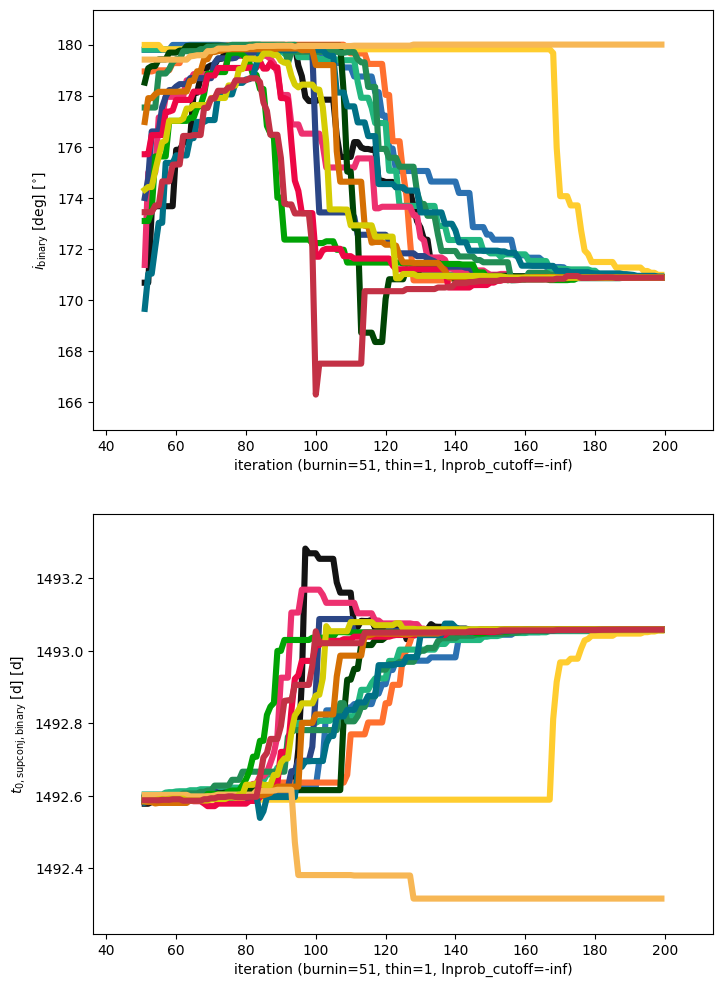

Finite: 3200 / 3200
-inf: 0
NaN: 0
{'outside parameter limits': [[180.5284711151904, 1492.5998937289924], [192.35425001262115, 1492.6236988088876], [188.38005417882414, 1492.6223334886713], [193.7831020253833, 1492.6347203843015], [186.3378633111826, 1492.6193883842802], [188.9693252678466, 1492.6238380683922], [180.30082550380394, 1492.6042415316927], [182.1499827788933, 1492.61487633569], [188.80801294886675, 1492.6156806770598], [190.4726611746161, 1492.6273297964442], [182.37552779269086, 1492.596611506012], [185.70020578016334, 1492.620277184989], [181.2108750501763, 1492.6019453936603], [180.57226213761356, 1492.604729153602], [188.3996176413078, 1492.6132344174025], [180.43044169952913, 1492.6040732338313], [180.0525175501484, 1492.602940024625], [183.19728665574706, 1492.6032106121916], [180.07954149530053, 1492.5915271904191], [184.1601804988681, 1492.60572725965], [180.79459634816592, 1492.6075344639557], [187.3792447804485, 1492.6226270731427], [186.0068881937665, 1492.61193

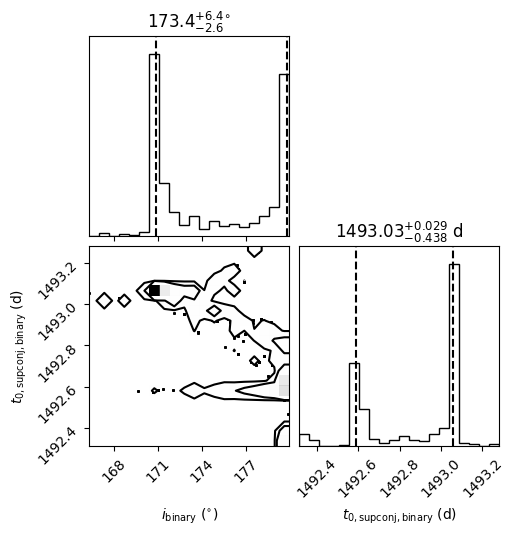

In [8]:
b = phoebe.load("tic_106588577_final.phoebe")

print(b.filter(context="solution", solution="emcee_solution"))

_ = b.plot("emcee_solution", style="trace", show=True)

import numpy as np

lnp = np.asarray(
    b.get_value(
        "lnprobabilities",
        solution="emcee_solution",
        context="solution",
    )
)

print("Finite:", np.isfinite(lnp).sum(), "/", lnp.size)
print("-inf:", np.isneginf(lnp).sum())
print("NaN:", np.isnan(lnp).sum())

print(
    b.get_value(
        "failed_samples",
        solution="emcee_solution",
        context="solution",
    )
)

_ = b.plot(
    "emcee_solution",
    style="corner",
    show=True,
)

# _ = b.plot("emcee_solution", style="corner", show=True)

# b.run_compute(
#     compute="phoebe01",
#     sample_from="emcee_solution",
#     sample_num=20,
#     sample_mode="3-sigma",
#     model="emcee_posterior_models",
#     overwrite=True,
# )

# _ = b.plot(
#     model="final_model",
#     dataset="lc01",
#     x="phases:primary",
#     show=True
#     )

# _ = b.plot(model="final_model",
#             x='phases:primary', 
#            linestyle={'model': 'solid'},
#            y='residuals',
#            legend=True,
#            show=True)